In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')


In [2]:
X_train = np.load("../data/processed/X_train_balanced.npy")
y_train = np.load("../data/processed/y_train_balanced.npy")
X_test = np.load("../data/processed/X_test_scaled.npy")
y_test = np.load("../data/processed/y_test.npy")

In [3]:
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")


Training data shape: (10167052, 13)
Test data shape: (1272524, 13)


In [4]:
model = GaussianNB()
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


In [5]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [6]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))


=== Classification Report ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.70      0.82   1270881
       Fraud       0.00      1.00      0.01      1643

    accuracy                           0.70   1272524
   macro avg       0.50      0.85      0.42   1272524
weighted avg       1.00      0.70      0.82   1272524



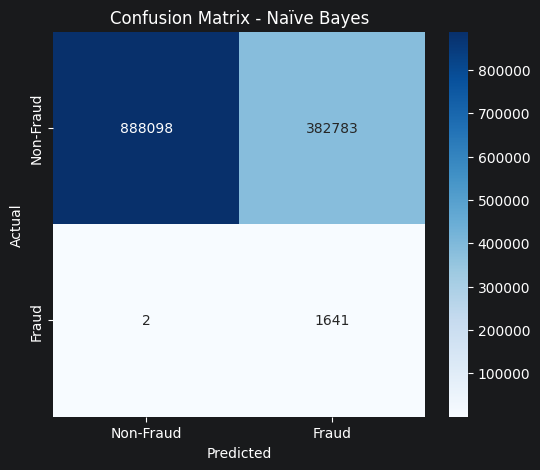

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix - Naïve Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("../data/processed/cm_naive_bayes.png")
plt.show()


In [8]:
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")



ROC-AUC Score: 0.9836


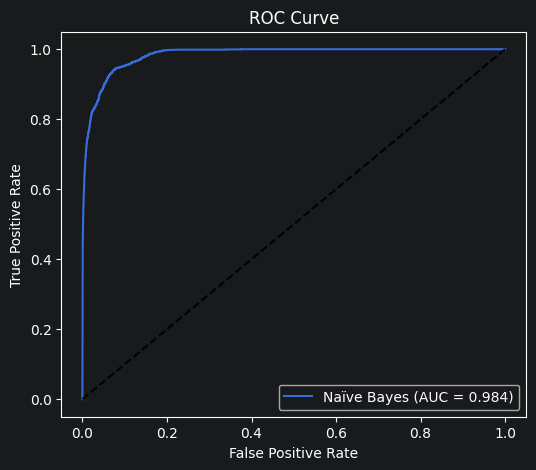

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Naïve Bayes (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig("../data/processed/roc_naive_bayes.png")
plt.show()


In [10]:
joblib.dump(model, "../models/naive_bayes.pkl")
print("✅ Model saved as ../models/naive_bayes.pkl")

✅ Model saved as ../models/naive_bayes.pkl
